<a href="https://colab.research.google.com/github/AnanyarajS/neuro_symbolic_ai/blob/main/code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'ananyarajshekhar'
os.environ['KAGGLE_KEY'] = 'KGAT_f0d724819afd785cf4a6e79ea764e069'

In [ ]:
!kaggle datasets download -d iamtanmayshukla/pneumonia-radiography-dataset

Dataset URL: https://www.kaggle.com/datasets/iamtanmayshukla/pneumonia-radiography-dataset
License(s): CC0-1.0
100% 1.13G/1.13G [00:11<00:00, 103MB/s] 



In [ ]:
!unzip -q pneumonia-radiography-dataset.zip

In [ ]:
import os
print(os.listdir())

['.config', 'pneumonia-radiography-dataset.zip', 'Radiography', 'sample_data']


In [ ]:
print(os.listdir("Radiography"))

['train', 'val', 'test']


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
        transforms.ToTensor(),


])

# Paths
train_data = datasets.ImageFolder("Radiography/train", transform=transform)
val_data   = datasets.ImageFolder("Radiography/val", transform=transform)
test_data  = datasets.ImageFolder("Radiography/test", transform=transform)

# Loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32)
test_loader  = DataLoader(test_data, batch_size=32)

print("Classes:", train_data.classes)

Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 2)
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
train_losses = []
val_losses = []
train_acc_list = []
val_acc_list = []

In [ ]:
epochs = 3

for epoch in range(epochs):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_acc_list.append(train_acc)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print("-"*40)

Epoch 1
Train Acc: 98.72% | Val Acc: 62.50%
Train Loss: 0.0340 | Val Loss: 0.5904
----------------------------------------
Epoch 2
Train Acc: 99.33% | Val Acc: 81.25%
Train Loss: 0.0203 | Val Loss: 0.2807
----------------------------------------
Epoch 3
Train Acc: 99.41% | Val Acc: 87.50%
Train Loss: 0.0161 | Val Loss: 0.3387
----------------------------------------


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 80.82474226804123


In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

gradients = []
activations = []

def save_grad(module, grad_in, grad_out):
    gradients.append(grad_out[0])

def save_act(module, inp, out):
    activations.append(out)

In [ ]:
target_layer = model.layer4[-1]

target_layer.register_forward_hook(save_act)
target_layer.register_backward_hook(save_grad)

In [ ]:
def gradcam(image):
    model.eval()

    gradients.clear()
    activations.clear()

    image = image.to(device)
    output = model(image)

    pred = output.argmax(dim=1).item()
    score = output[0, pred]

    model.zero_grad()
    score.backward()

    print("Gradients:", len(gradients))  # debug
    print("Activations:", len(activations))

    grads = gradients[0].detach().cpu().numpy()[0]
    acts = activations[0].detach().cpu().numpy()[0]

    weights = np.mean(grads, axis=(1, 2))

    cam = np.zeros(acts.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam, pred

In [ ]:
gradients = []
activations = []

In [ ]:
def get_last_conv_layer(model):
    for name, module in reversed(list(model.named_modules())):
        if isinstance(module, torch.nn.Conv2d):
            print("Using layer:", name)
            return module
    raise Exception("No Conv2d layer found in model")

In [ ]:
def forward_hook(module, inp, out):
    activations.append(out)

def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

In [ ]:
target_layer = get_last_conv_layer(model)

target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

Using layer: layer4.1.conv2


Gradients: 1
Activations: 1


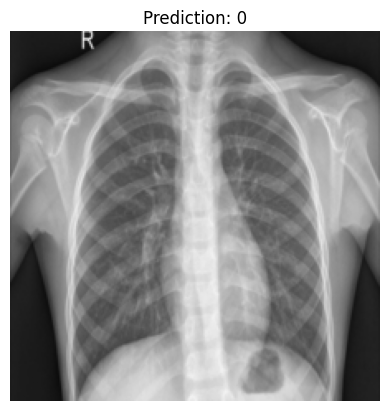

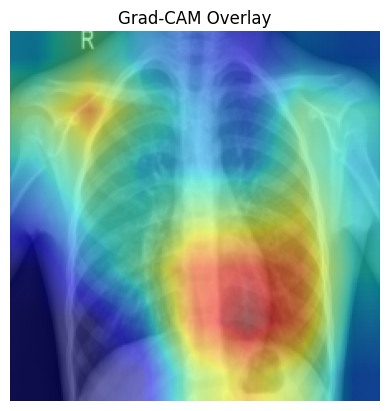

In [ ]:
images, labels = next(iter(test_loader))
image = images[0].unsqueeze(0).to(device)

cam, pred = gradcam(image)

img = image[0].detach().cpu().permute(1,2,0).numpy()

plt.imshow(img)
plt.title(f"Prediction: {pred}")
plt.axis('off')
plt.show()

plt.imshow(img)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title("Grad-CAM Overlay")
plt.axis('off')
plt.show()

In [ ]:
def extract_features(cam):
    binary = cam > 0.5

    area = np.sum(binary) / (224 * 224)

    left = np.sum(binary[:, :112])
    right = np.sum(binary[:, 112:])

    side = "LEFT" if left > right else "RIGHT"

    return {
        "area": area,
        "side": side
    }

In [ ]:
def reason(features, confidence):

    area = features["area"]
    side = features["side"]

    # --- Severity based on area ---
    if area < 0.1:
        severity = "MILD"
    elif area < 0.3:
        severity = "MODERATE"
    else:
        severity = "SEVERE"

    # --- Diagnosis based on confidence ---
    if confidence > 0.75:
        diagnosis = "PNEUMONIA"
    elif confidence > 0.5:
        diagnosis = "LIKELY PNEUMONIA"
    else:
        diagnosis = "UNCERTAIN"

    # --- Risk (combine area + spread) ---
    if side == "BOTH" or area > 0.3:
        risk = "HIGH"
    elif area > 0.15:
        risk = "MEDIUM"
    else:
        risk = "LOW"

    # --- Confidence reliability flag ---
    if confidence < 0.5:
        reliability = "LOW CONFIDENCE"
    elif confidence < 0.75:
        reliability = "MODERATE CONFIDENCE"
    else:
        reliability = "HIGH CONFIDENCE"

    # --- Explanation (this is 🔥 for viva) ---
    explanation = (
        f"The model predicts {diagnosis.lower()} with {confidence:.2f} confidence. "
        f"The affected lung area is {area:.2f}, indicating {severity.lower()} severity. "
        f"The infection is {('bilateral' if side == 'BOTH' else 'localized')} "
        f"leading to a {risk.lower()} risk assessment."
    )

    return {
        "diagnosis": diagnosis,
        "severity": severity,
        "risk": risk,
        "reliability": reliability,
        "explanation": explanation
    }

In [ ]:
def full_system(image):

    cam, pred = gradcam(image)

    confidence = torch.softmax(model(image.to(device)), dim=1)[0][pred].item()

    features = extract_features(cam)

    result = reason(features, confidence)

    return cam, features, result, confidence

In [ ]:
cam, features, result, confidence = full_system(image)

print("Confidence:", confidence)
print("Features:", features)
print("Result:", result)

Gradients: 1
Activations: 1
Confidence: 0.8252967000007629
Features: {'area': np.float64(0.28324298469387754), 'side': 'RIGHT'}
Result: {'diagnosis': 'PNEUMONIA', 'severity': 'MODERATE', 'risk': 'MEDIUM', 'reliability': 'HIGH CONFIDENCE', 'explanation': 'The model predicts pneumonia with 0.83 confidence. The affected lung area is 0.28, indicating moderate severity. The infection is localized leading to a medium risk assessment.'}


In [ ]:
def nesy_reasoning(features, confidence):

    area = features.get("area", 0)
    side = features.get("side", "unknown")   # left/right/bilateral
    spread = features.get("spread", 0)
    lower = features.get("lower_zone", 0)
    upper = features.get("upper_zone", 0)

    explanation = []
    score = 0
    flags = []


    explanation.append(f"Infected area: {area*100:.1f}%")
    explanation.append(f"Affected region: {side.capitalize()}")

    if spread > 0.5:
        explanation.append("Observation: Diffuse infection pattern")
        score += 1
    else:
        explanation.append("Observation: Localized infection pattern")

    if lower > upper:
        explanation.append("Observation: Lower lung dominance")
        score += 1


    if area > 0.5:
        explanation.append("Rule: Extensive involvement → Severe pneumonia")
        score += 3
    elif area > 0.2:
        explanation.append("Rule: Moderate involvement → Moderate pneumonia")
        score += 2
    elif area > 0:
        explanation.append("Rule: Small involvement → Mild pneumonia")
        score += 1

    if side == "bilateral":
        explanation.append("Rule: Both lungs affected → Increased severity")
        score += 2


    if confidence > 0.8:
        explanation.append("Rule: High model confidence")
        score += 1
    elif 0.4 < confidence < 0.6:
        explanation.append("Rule: Uncertain prediction → Needs review")
        flags.append("UNCERTAIN")

    if confidence > 0.8 and area < 0.1:
        flags.append("HIGH_CONF_LOW_EVIDENCE")
        explanation.append("Warning: High confidence but weak visual evidence")

    if confidence < 0.4 and area > 0.3:
        flags.append("LOW_CONF_HIGH_EVIDENCE")
        explanation.append("Warning: Low confidence despite strong infection features")


    if "HIGH_CONF_LOW_EVIDENCE" in flags:
        final = "Uncertain (Model overconfidence detected)"

    elif score >= 5:
        final = "Severe Pneumonia"

    elif score >= 3:
        final = "Moderate Pneumonia"

    elif score >= 1:
        final = "Mild Pneumonia"

    else:
        final = "Normal"


    explanation.append(f"\nFinal Decision: {final}")

    if flags:
        explanation.append(f"Flags: {', '.join(flags)}")

    return final, "\n\n".join(explanation)

In [ ]:
nesy_reasoning(features, confidence)

('Moderate Pneumonia',
 'Infected area: 28.3%\n\nAffected region: Right\n\nObservation: Localized infection pattern\n\nRule: Moderate involvement → Moderate pneumonia\n\nRule: High model confidence\n\n\nFinal Decision: Moderate Pneumonia')